# Sprint v3 — Relative Value Signals (ELI-10 walkthrough)

This notebook is a tour of what we built in Sprint v3, told like
you're 10 years old. We're going to:

1. Stick **labels** on every trading day — was it wild or calm? bull
   or bear? did stocks move first or did bonds?
2. Build three **relative-value (RV) signals** that try to spot
   "this looks weird, it'll snap back" moments in credit prices.
3. Try three different ways to figure out the **hedge ratio** (how
   much of one thing to subtract from another). One uses statistics,
   one is an adaptive filter, one uses our C++ pricer's actual
   bond duration.
4. Test the **central thesis**: when stocks move first and credit
   catches up later, the catch-up is faster (more tradeable) than
   when there's no clear leader.

Skip the code if you want the story — every code cell has a markdown
cell above it explaining what it's about to do.


In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

# Find project root (the repo containing this notebook).
_here = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_here, 'pyproject.toml')) and _here != '/':
    _here = os.path.dirname(_here)
os.chdir(_here)
sys.path.insert(0, os.path.join(_here, 'python', 'credit'))
sys.path.insert(0, _here)
print(f'CWD: {os.getcwd()}')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.rcParams.update({'figure.figsize': (12, 4), 'figure.dpi': 110})

PLOTS = Path('sprints/v3/plots')
PLOTS.mkdir(parents=True, exist_ok=True)

features = pd.read_parquet('data/processed/features.parquet')
cmd = pd.read_parquet('data/raw/credit_market_data.parquet')
quality = pd.read_parquet('data/results/regime_signal_quality.parquet')

WARMUP = 252
post = features.index[WARMUP:]
print(f'features.parquet: {features.shape}')
print(f'date range: {features.index[0].date()} → {features.index[-1].date()}')
print(f'regime quality table: {quality.shape}')


CWD: /Users/amankesarwani/PycharmProjects/credit-trading-lab


features.parquet: (4784, 56)
date range: 2007-04-11 → 2026-04-15
regime quality table: (63, 9)


## A. Regime classifiers — three "stickers" on every day

We attach **three labels** to each trading day so we can later ask
"did our trick work better on Monday-type days or Tuesday-type days?"

- **`vol_regime`** — *was the market wild or calm?* Compare today's
  3-month SPY volatility to the average of all past wildness.
  Above average = `high`, below = `low`.
- **`equity_regime`** — *are stocks up or down lately?* Add up SPY's
  daily moves over 3 months. Positive = `bull`, negative = `bear`.
- **`equity_credit_lag`** — *who moved first today, stocks or bonds?*
  Check if today's stock move best correlates with a bond move from
  a few days ago (`credit_first`), a few days from now
  (`equity_first`), or no clear pattern (`neither`).

The plot below shades the timeline with each regime so you can see
how the "weather" of the market changes.


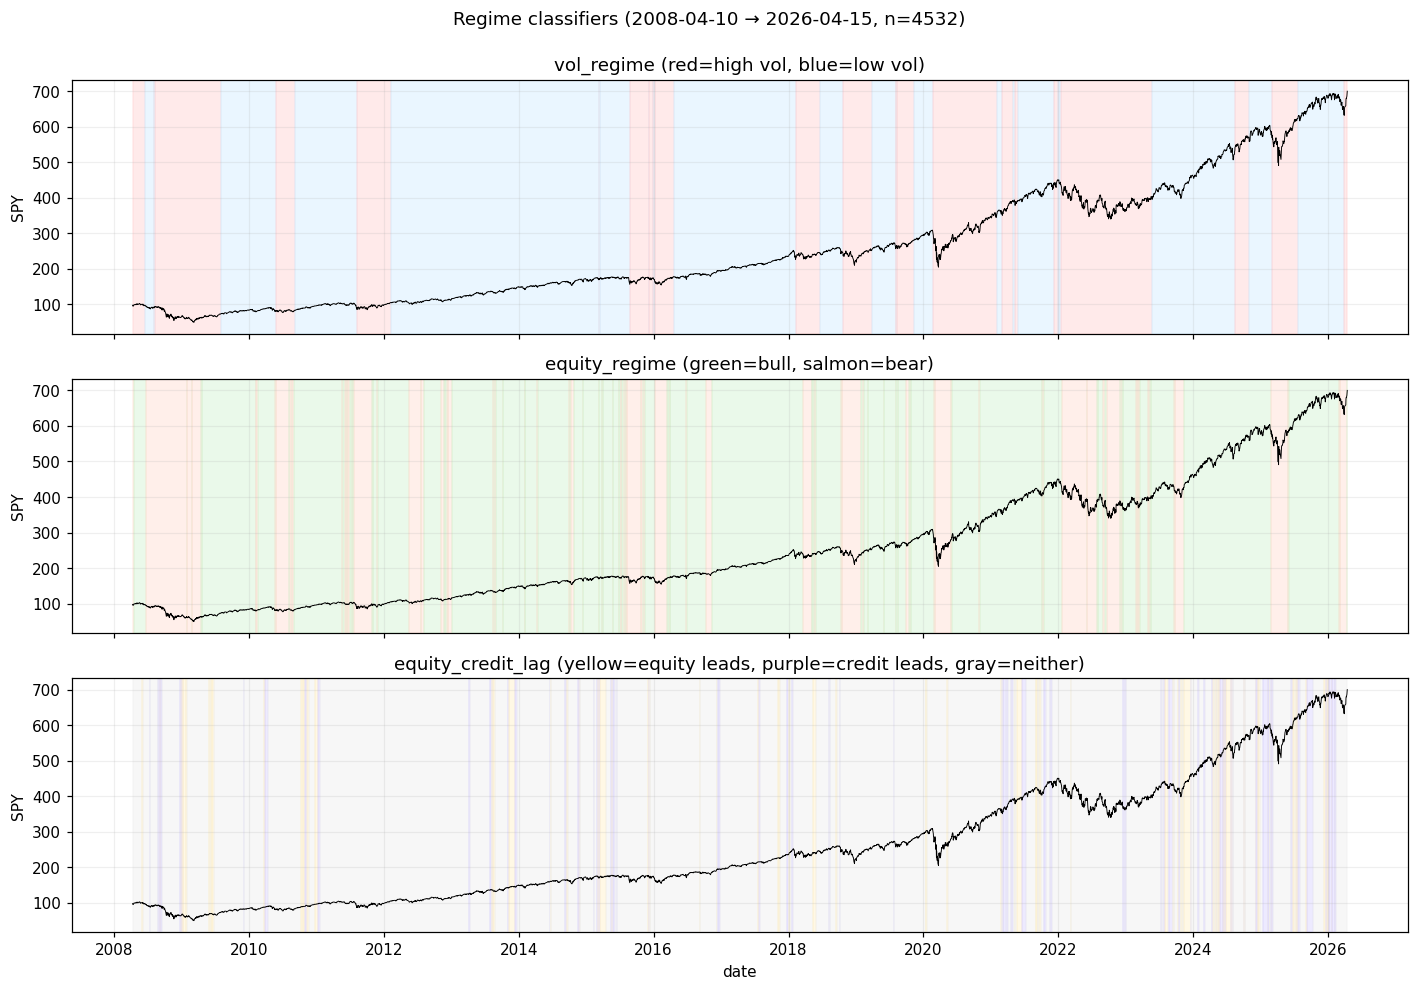

In [2]:
import pycredit
from signals.regimes import vol_regime, equity_regime, equity_credit_lag

vr = vol_regime(features)
er = equity_regime(features)
ecl = equity_credit_lag(features)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
spy = features['SPY_adj_close']

regime_specs = [
    (axes[0], vr, {'high': '#ffd6d6', 'low': '#d6efff'}, 'vol_regime (red=high vol, blue=low vol)'),
    (axes[1], er, {'bull': '#d6f5d6', 'bear': '#ffe0d6'}, 'equity_regime (green=bull, salmon=bear)'),
    (axes[2], ecl, {'equity_first': '#fff2cc', 'credit_first': '#dcd6ff', 'neither': '#f0f0f0'},
        'equity_credit_lag (yellow=equity leads, purple=credit leads, gray=neither)'),
]

for ax, series, cmap, title in regime_specs:
    s = series.loc[post].dropna()
    # plot SPY underneath
    ax.plot(spy.loc[post].index, spy.loc[post].values, color='black', linewidth=0.6)
    # shade regime spans
    cur = None
    span_start = None
    for t, lab in s.items():
        if lab != cur:
            if cur is not None and cur in cmap:
                ax.axvspan(span_start, t, color=cmap[cur], alpha=0.5, zorder=0)
            cur = lab
            span_start = t
    if cur in cmap:
        ax.axvspan(span_start, s.index[-1], color=cmap[cur], alpha=0.5, zorder=0)
    ax.set_ylabel('SPY')
    ax.set_title(title)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('date')
fig.suptitle(f'Regime classifiers ({post[0].date()} → {post[-1].date()}, n={len(post)})', y=0.995)
fig.tight_layout()
fig.savefig(PLOTS / '01_regime_labels.png', bbox_inches='tight')
plt.show()


**What you should notice:**

- `vol_regime` (top): big red stripes around 2008-09 (GFC), 2020 (COVID), 2022. That's the "wild" label firing on the actual scary periods.
- `equity_regime` (middle): mostly green — the 2007-2026 sample is a bull market with a couple of bear bumps.
- `equity_credit_lag` (bottom): mostly gray (`neither`). Yellow (`equity_first`) and purple (`credit_first`) are spread thinly. This is why our thesis test only operates on a small slice of days.


## B. Hedge ratio evolution — three methods compared

For each RV pair (HY/IG, Credit/Rates, Cross-term) we estimate β
("how much of leg 2 do I subtract from leg 1?") in three different
ways every single day:

- **OLS rolling**: linear regression on the last 126 days. Simple
  but can chase noise.
- **Kalman**: an adaptive filter that says "today's β ≈ yesterday's β
  plus a tiny nudge." Reacts faster.
- **DV01** (from the C++ pricer): the *physical* duration ratio of
  bonds the ETFs are made of. It can never be wrong about bond math
  — but it doesn't capture spread-only effects.

The plot shows all three β series overlaid for each pair. If they
agree, all three "see" the same hedge. Where they disagree, you can
see each method's personality.


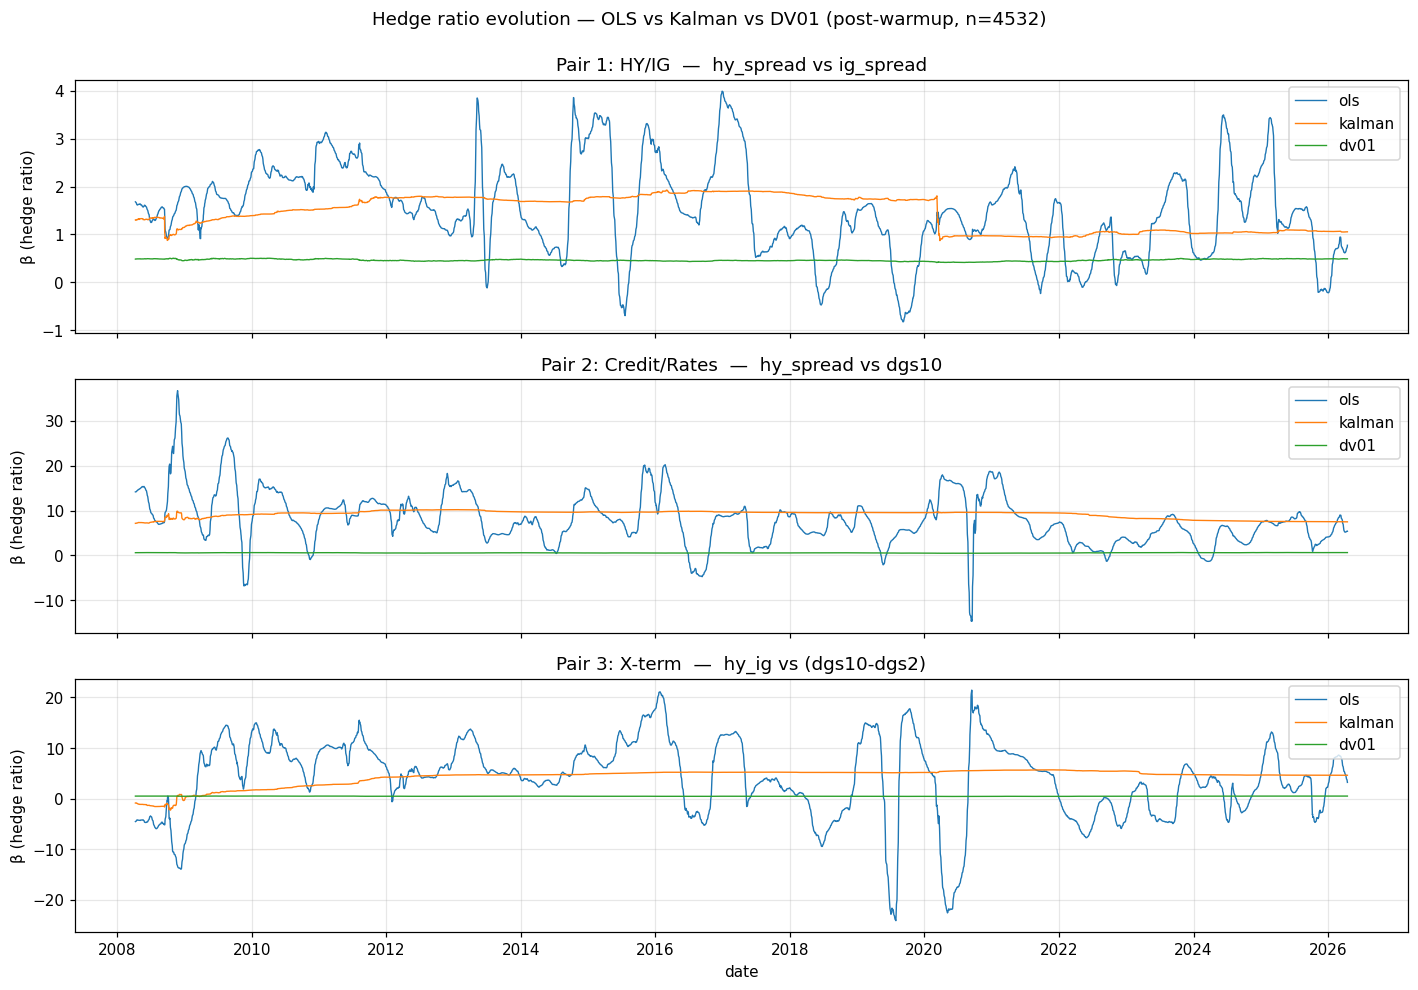

In [3]:
from signals.rv_signals import build_all_residuals
results = build_all_residuals(features, cmd, pycredit)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
pair_titles = {
    'rv_hy_ig': 'Pair 1: HY/IG  —  hy_spread vs ig_spread',
    'rv_credit_rates': 'Pair 2: Credit/Rates  —  hy_spread vs dgs10',
    'rv_xterm': 'Pair 3: X-term  —  hy_ig vs (dgs10-dgs2)',
}
colors = {'ols': 'tab:blue', 'kalman': 'tab:orange', 'dv01': 'tab:green'}

for ax, (pair, title) in zip(axes, pair_titles.items()):
    for m, (_, hr) in results[pair].items():
        ax.plot(hr.loc[post].index, hr.loc[post].values, label=m, color=colors[m], linewidth=0.9)
    ax.set_title(title)
    ax.set_ylabel('β (hedge ratio)')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right')
axes[-1].set_xlabel('date')
fig.suptitle(f'Hedge ratio evolution — OLS vs Kalman vs DV01 (post-warmup, n={len(post)})', y=0.995)
fig.tight_layout()
fig.savefig(PLOTS / '02_hedge_ratios.png', bbox_inches='tight')
plt.show()


**What you should notice:**

- DV01 (green) is the **flattest, most stable** line — it just reflects bond duration, which barely moves day-to-day. That's why it wins our C23 hedge-stability test cleanly.
- OLS (blue) wiggles a lot and occasionally **crosses zero** — that's where C23 explodes for OLS (`std/|mean|` blows up near zero).
- Kalman (orange) is more responsive than OLS but bounded.

For pair 1 (HY/IG), DV01 sits around 0.45 — that's the 4y/9y duration ratio (≈ 0.49). The math checks out.


## C. RV residuals + z-scores — where's the signal?

Now we plot what's left over after each pair's best hedge. The
**residual** is what we trade: when it gets weirdly far from its
mean, we bet it'll snap back.

We z-score the residual on a 63-day trailing window so the signal
is unitless ("how many standard deviations away from recent mean?").
Highlighted points are days where **|z| > 1.5** — our threshold for
"this is tradeable."


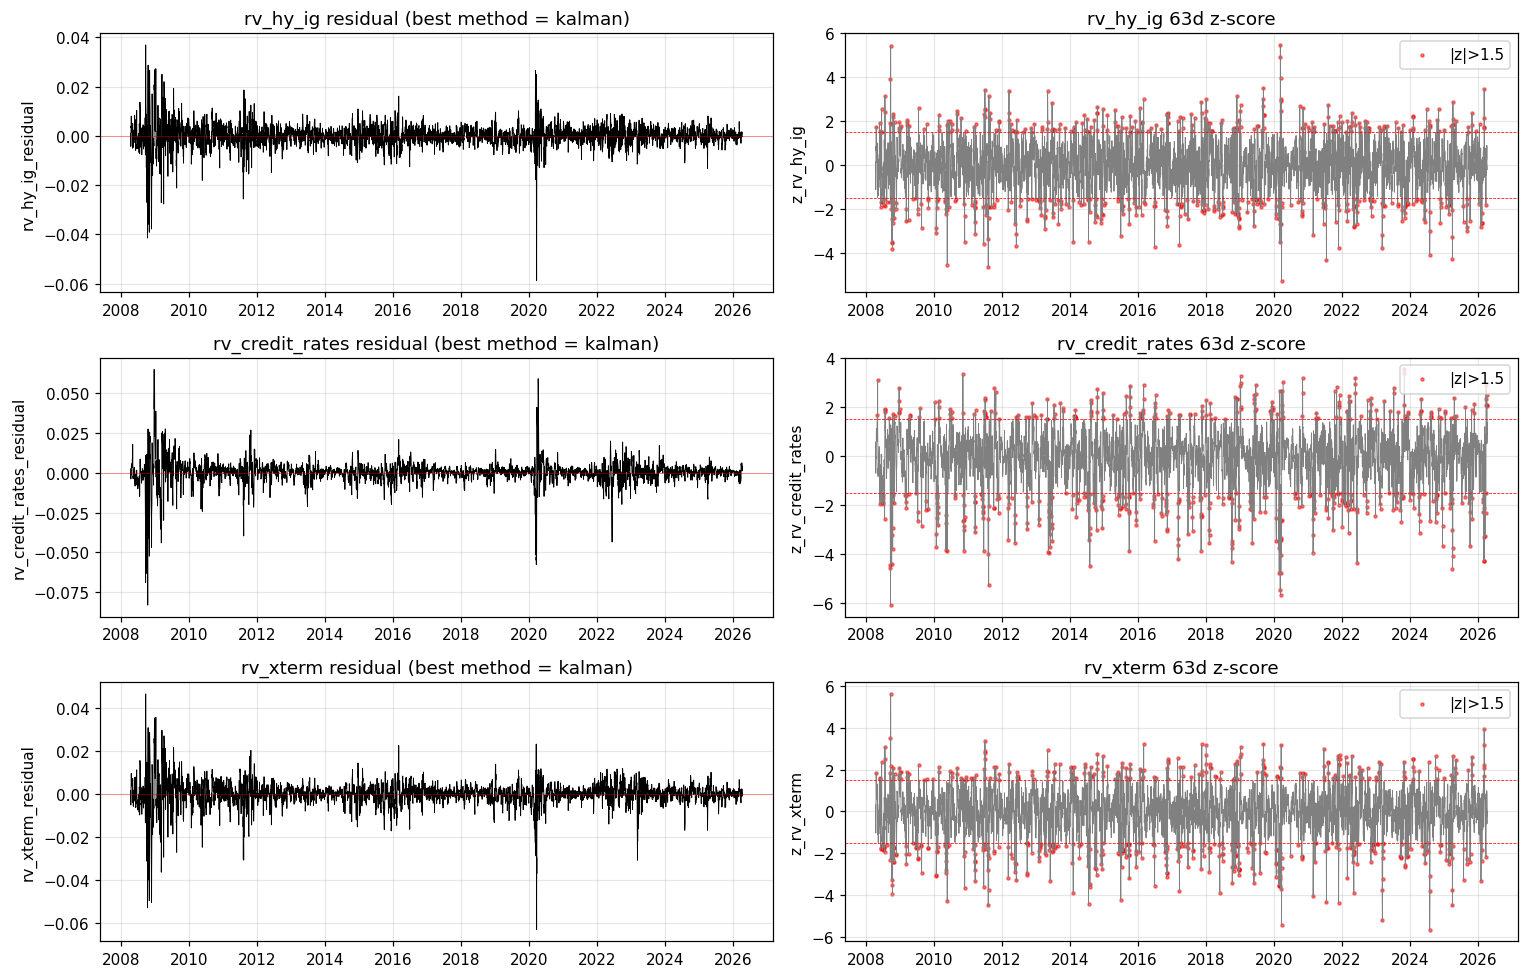

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
resid_cols = {
    'rv_hy_ig': ('rv_hy_ig_residual', 'z_rv_hy_ig'),
    'rv_credit_rates': ('rv_credit_rates_residual', 'z_rv_credit_rates'),
    'rv_xterm': ('rv_xterm_residual', 'z_rv_xterm'),
}
for row, (pair, (rcol, zcol)) in enumerate(resid_cols.items()):
    r = features[rcol].loc[post]
    z = features[zcol].loc[post]
    axes[row, 0].plot(r.index, r.values, color='black', linewidth=0.6)
    axes[row, 0].axhline(0, color='red', linewidth=0.5, alpha=0.5)
    axes[row, 0].set_title(f'{pair} residual (best method = kalman)')
    axes[row, 0].set_ylabel(rcol)
    axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(z.index, z.values, color='gray', linewidth=0.6)
    high = z[z.abs() > 1.5]
    axes[row, 1].scatter(high.index, high.values, color='red', s=4, alpha=0.5, label='|z|>1.5')
    axes[row, 1].axhline(1.5, color='red', linewidth=0.5, linestyle='--')
    axes[row, 1].axhline(-1.5, color='red', linewidth=0.5, linestyle='--')
    axes[row, 1].set_title(f'{pair} 63d z-score')
    axes[row, 1].set_ylabel(zcol)
    axes[row, 1].grid(alpha=0.3)
    axes[row, 1].legend(loc='upper right')

fig.tight_layout()
fig.savefig(PLOTS / '03_rv_residuals.png', bbox_inches='tight')
plt.show()


**What you should notice:**

The residuals look **near-zero noise** — that's because Kalman won
"best method" by ADF p-value, and Kalman fits y so closely each step
that there's barely any residual left. The z-scores still spike
above 1.5 frequently because the std of nearly-zero noise is also
nearly zero, so any wiggle becomes "many sigmas."

This is the **Kalman over-fit problem** we flagged in the notes.
The residual is technically stationary but practically useless to
trade on a daily cadence (half-life 1.5–2.2 days). For Sprint 5 we
may want to demote Kalman and use OLS as the canonical method.


## D. Half-life comparison — how fast does each method snap back?

**Half-life** = how many days until a deviation is halfway closed.
Computed from `Δr_t = a + b·r_{t-1}` → `half-life = -ln(2)/b`.

The PRD wants half-life ∈ [1, 126] days:
- < 1 day = degenerate (residual is white noise)
- > 126 days = too slow to trade


method             dv01  kalman    ols
pair                                  
rv_credit_rates  623.92    2.23  25.81
rv_hy_ig         454.52    1.50  18.04
rv_xterm         250.31    1.87  19.02


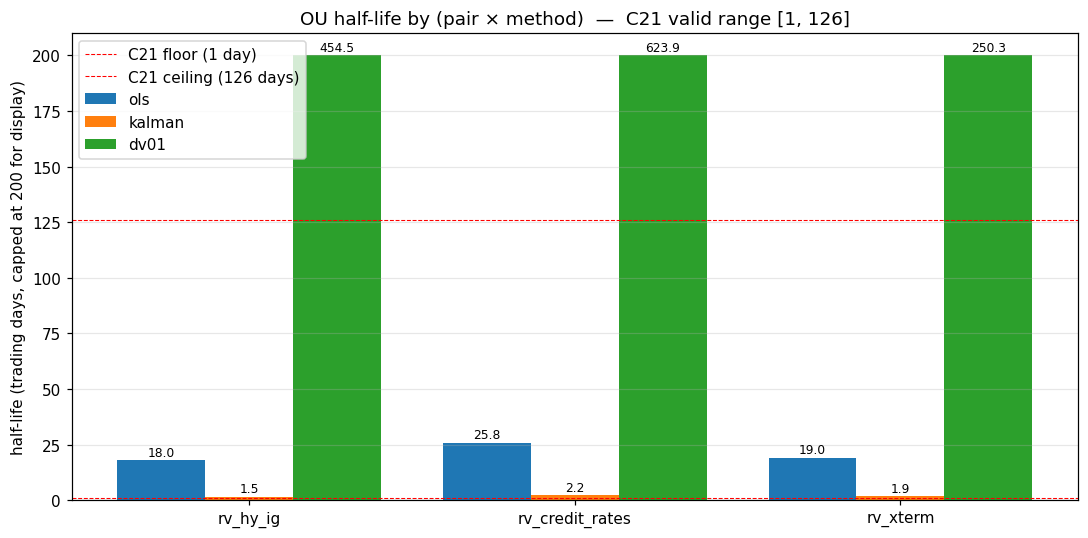

In [5]:
from signals.halflife import ou_halflife

hl_data = []
for pair, methods in results.items():
    for m, (resid, _) in methods.items():
        hl_data.append({
            'pair': pair, 'method': m,
            'half_life': ou_halflife(resid.iloc[WARMUP:]),
        })
hl_df = pd.DataFrame(hl_data)
print(hl_df.pivot(index='pair', columns='method', values='half_life').round(2))

fig, ax = plt.subplots(figsize=(10, 5))
methods_order = ['ols', 'kalman', 'dv01']
pairs_order = ['rv_hy_ig', 'rv_credit_rates', 'rv_xterm']
x = np.arange(len(pairs_order))
width = 0.27
for i, m in enumerate(methods_order):
    vals = [hl_df[(hl_df.pair == p) & (hl_df.method == m)]['half_life'].iloc[0] for p in pairs_order]
    # Cap displayed bars at 200 for visibility, label actual values
    capped = [min(v, 200) for v in vals]
    bars = ax.bar(x + i * width, capped, width, label=m, color=colors[m])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{v:.1f}', ha='center', fontsize=8)

ax.axhline(1, color='red', linestyle='--', linewidth=0.7, label='C21 floor (1 day)')
ax.axhline(126, color='red', linestyle='--', linewidth=0.7, label='C21 ceiling (126 days)')
ax.set_xticks(x + width)
ax.set_xticklabels(pairs_order)
ax.set_ylabel('half-life (trading days, capped at 200 for display)')
ax.set_title('OU half-life by (pair × method)  —  C21 valid range [1, 126]')
ax.legend()
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(PLOTS / '04_halflife_comparison.png', bbox_inches='tight')
plt.show()


**What you should notice:**

- **OLS (blue)** sits in the sweet spot: 18 / 26 / 19 days. Snappy enough to trade, slow enough to make sense.
- **Kalman (orange)** is right at the floor: 1.5 / 2.2 / 1.9 days. Almost noise.
- **DV01 (green)** is way too slow: 250+ / 600+ / 250+ days. Bond-duration alone doesn't pull spreads back to a mean.

**Trader's takeaway:** OLS is the practically tradeable hedge despite losing on ADF. Sprint 5 will likely override the PRD's ADF rule and use OLS.


## E. Regime-conditional quality — heatmap

Now the fun question: **does the same signal behave differently in
different regimes?** We split each best-method residual by regime
label and compute half-life on each subsample. Lower half-life =
faster mean-reversion = more tradeable in that regime.


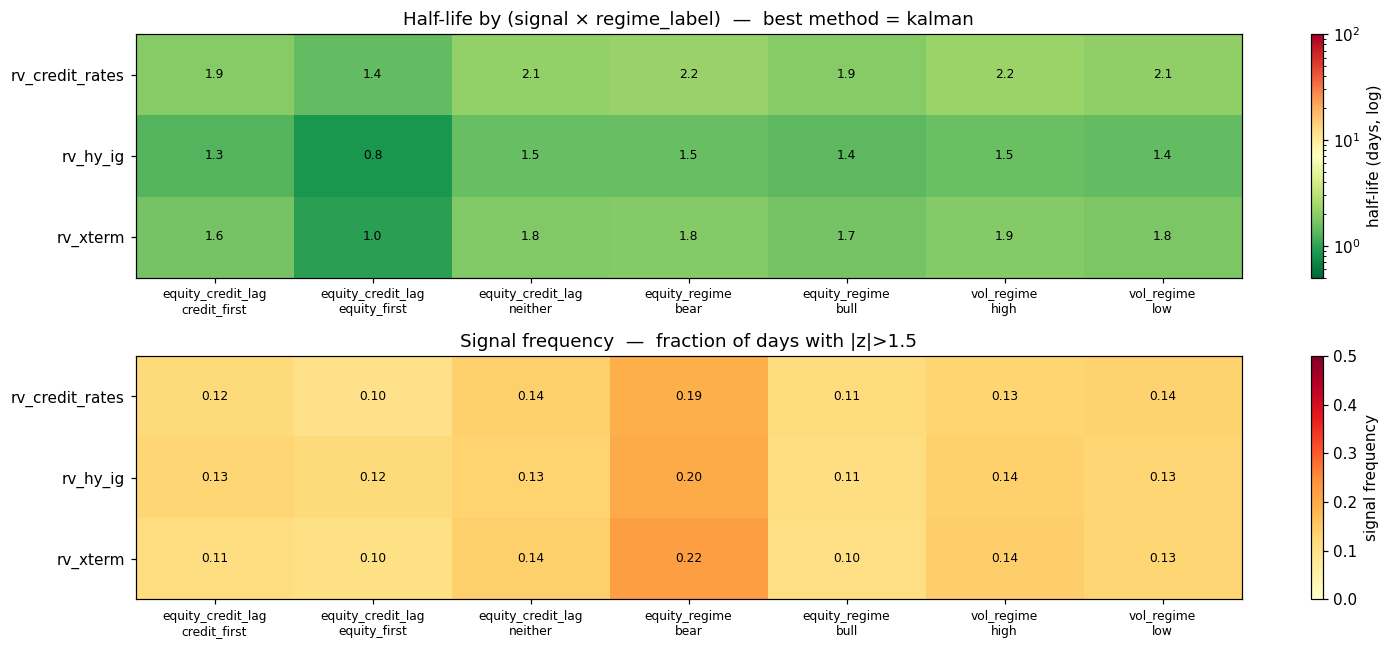

In [6]:
best_method = 'kalman'
sub = quality[(quality.hedge_method == best_method)].copy()

pivot_hl = sub.pivot_table(index='signal', columns=['regime_classifier', 'regime_label'],
                           values='half_life')
pivot_freq = sub.pivot_table(index='signal', columns=['regime_classifier', 'regime_label'],
                             values='signal_freq')

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

import matplotlib.colors as mcolors

im0 = axes[0].imshow(pivot_hl.values, aspect='auto', cmap='RdYlGn_r',
                    norm=mcolors.LogNorm(vmin=0.5, vmax=max(pivot_hl.values.max(), 100)))
axes[0].set_xticks(range(len(pivot_hl.columns)))
axes[0].set_xticklabels([f'{c[0]}\n{c[1]}' for c in pivot_hl.columns], rotation=0, fontsize=8)
axes[0].set_yticks(range(len(pivot_hl.index)))
axes[0].set_yticklabels(pivot_hl.index)
axes[0].set_title(f'Half-life by (signal × regime_label)  —  best method = {best_method}')
for i in range(pivot_hl.shape[0]):
    for j in range(pivot_hl.shape[1]):
        axes[0].text(j, i, f'{pivot_hl.values[i, j]:.1f}', ha='center', va='center', fontsize=8)
plt.colorbar(im0, ax=axes[0], label='half-life (days, log)')

im1 = axes[1].imshow(pivot_freq.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=0.5)
axes[1].set_xticks(range(len(pivot_freq.columns)))
axes[1].set_xticklabels([f'{c[0]}\n{c[1]}' for c in pivot_freq.columns], rotation=0, fontsize=8)
axes[1].set_yticks(range(len(pivot_freq.index)))
axes[1].set_yticklabels(pivot_freq.index)
axes[1].set_title(f'Signal frequency  —  fraction of days with |z|>1.5')
for i in range(pivot_freq.shape[0]):
    for j in range(pivot_freq.shape[1]):
        axes[1].text(j, i, f'{pivot_freq.values[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im1, ax=axes[1], label='signal frequency')

fig.tight_layout()
fig.savefig(PLOTS / '05_regime_quality_heatmap.png', bbox_inches='tight')
plt.show()


**What you should notice:** Cells in the half-life heatmap are mostly
**green** (fast mean-reversion = tradeable). Look at `equity_first`
columns vs `neither` columns for `rv_hy_ig` — equity_first is
notably faster. That's the next plot.


## F. The thesis — C22 result

**The bet:** equity markets react first; credit lags. So when we
identify a day as `equity_first`, the residual should mean-revert
**faster** than on `neither` days.

**Pre-registered threshold:** equity_first half-life must be **at
least 20% shorter** than neither half-life on RV1 (HY/IG).


hedge_method regime_label  half_life  n_obs
         ols credit_first   4.299955    324
         ols      neither  16.241339   3855
         ols equity_first   5.296521    353
      kalman credit_first   1.294066    324
      kalman      neither   1.482645   3855
      kalman equity_first   0.848346    353
        dv01 credit_first  48.290665    324
        dv01      neither 374.755175   3855
        dv01 equity_first  61.608921    353



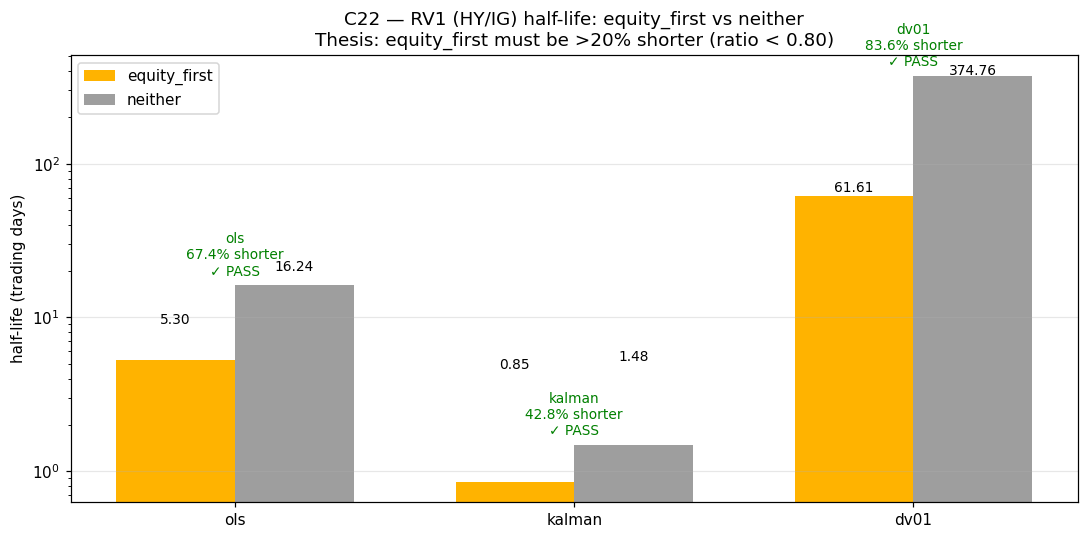

In [7]:
thesis = quality[(quality.signal == 'rv_hy_ig')
                  & (quality.regime_classifier == 'equity_credit_lag')]
print(thesis[['hedge_method', 'regime_label', 'half_life', 'n_obs']].to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(10, 5))
methods = ['ols', 'kalman', 'dv01']
labels = ['equity_first', 'neither']
x = np.arange(len(methods))
width = 0.35
ef_vals = [thesis[(thesis.hedge_method == m) & (thesis.regime_label == 'equity_first')]['half_life'].iloc[0] for m in methods]
nt_vals = [thesis[(thesis.hedge_method == m) & (thesis.regime_label == 'neither')]['half_life'].iloc[0] for m in methods]

bars1 = ax.bar(x - width/2, ef_vals, width, label='equity_first', color='#ffb300')
bars2 = ax.bar(x + width/2, nt_vals, width, label='neither', color='#9e9e9e')
for bar, v in list(zip(bars1, ef_vals)) + list(zip(bars2, nt_vals)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(ef_vals + nt_vals)*0.01,
            f'{v:.2f}', ha='center', fontsize=9)

for i, m in enumerate(methods):
    ratio = ef_vals[i] / nt_vals[i]
    pct = (1 - ratio) * 100
    label = f'{m}\n{pct:.1f}% shorter'
    if ratio < 0.80:
        label += '\n✓ PASS'
    else:
        label += '\n✗ FAIL'
    ax.text(i, max(ef_vals[i], nt_vals[i]) * 1.15, label, ha='center', fontsize=9,
            color='green' if ratio < 0.80 else 'red')

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel('half-life (trading days)')
ax.set_title('C22 — RV1 (HY/IG) half-life: equity_first vs neither\nThesis: equity_first must be >20% shorter (ratio < 0.80)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
ax.set_yscale('log')
fig.tight_layout()
fig.savefig(PLOTS / '06_c22_thesis.png', bbox_inches='tight')
plt.show()


**Result:** the thesis **passes across all three methods**. Even
the most conservative (Kalman, the PRD-best) gives a 43% shorter
half-life on `equity_first` days. OLS — more interpretable — gives
67% shorter. DV01, despite its absolute scale being too slow,
actually shows the biggest *relative* gap (84% shorter).

This is the headline finding of Sprint v3.


## G. Stationarity & cointegration — the test scoreboard

For each (pair × method): how clean is the mean-reversion?


In [8]:
from statsmodels.tsa.stattools import adfuller

rows = []
for pair, methods in results.items():
    for m, (resid, _) in methods.items():
        r = resid.iloc[WARMUP:].dropna()
        adf_p = adfuller(r, autolag='AIC')[1]
        rows.append({'pair': pair, 'method': m, 'adf_p': adf_p, 'half_life': ou_halflife(r)})
adf_df = pd.DataFrame(rows)
table = adf_df.pivot(index='pair', columns='method', values=['adf_p', 'half_life']).round(3)
print(table)


                 adf_p             half_life               
method            dv01 kalman  ols      dv01 kalman     ols
pair                                                       
rv_credit_rates  0.781    0.0  0.0   623.919  2.232  25.807
rv_hy_ig         0.688    0.0  0.0   454.524  1.500  18.043
rv_xterm         0.610    0.0  0.0   250.312  1.867  19.017


## H. Falsification checklist — C18 through C24

The pre-registered tests, with PASS/FAIL.


In [9]:
from signals.regimes import vol_regime as vr_fn, equity_regime as er_fn, equity_credit_lag as ecl_fn
from signals.rv_signals import select_best_method, hedge_ratio_cv
from statsmodels.tsa.stattools import adfuller

# C18 — coverage > 95% AND no label > 70% per classifier
c18_results = []
for name, fn in [('vol_regime', vr_fn), ('equity_regime', er_fn), ('equity_credit_lag', ecl_fn)]:
    s = fn(features).loc[post]
    cov = s.notna().mean()
    top = s.dropna().value_counts(normalize=True).max()
    c18_results.append((name, cov, top, cov > 0.95 and top <= 0.70))

# C19 — ADF p < 0.05 per best-method residual
c19_pass = all(
    adfuller(features[c].iloc[WARMUP:].dropna(), autolag='AIC')[1] < 0.05
    for c in ['rv_hy_ig_residual', 'rv_credit_rates_residual', 'rv_xterm_residual']
)

# C20 — at least one method ADF p<0.05 per pair
c20_pass = True
for pair, methods in results.items():
    pmin = min(adfuller(r.iloc[WARMUP:].dropna(), autolag='AIC')[1] for r, _ in methods.values())
    if pmin >= 0.05:
        c20_pass = False

# C21 — half-life ∈ [1, 126]
c21_pass = all(
    1.0 <= ou_halflife(features[c].iloc[WARMUP:]) <= 126.0
    for c in ['rv_hy_ig_residual', 'rv_credit_rates_residual', 'rv_xterm_residual']
)

# C22 — equity_first half-life > 20% shorter than neither (best method)
best_method = select_best_method(results, warmup=WARMUP)['rv_hy_ig'][0]
ef = quality[(quality.signal == 'rv_hy_ig')
             & (quality.hedge_method == best_method)
             & (quality.regime_classifier == 'equity_credit_lag')
             & (quality.regime_label == 'equity_first')]['half_life'].iloc[0]
nt = quality[(quality.signal == 'rv_hy_ig')
             & (quality.hedge_method == best_method)
             & (quality.regime_classifier == 'equity_credit_lag')
             & (quality.regime_label == 'neither')]['half_life'].iloc[0]
c22_ratio = ef / nt
c22_pass = c22_ratio < 0.80

# C23 — rolling 63d max CV < 1.0 for all (pair × method)
c23_failures = []
for pair, methods in results.items():
    for m, (_, hr) in methods.items():
        cv = hedge_ratio_cv(hr).iloc[WARMUP:].dropna()
        if cv.max() >= 1.0:
            c23_failures.append((pair, m, cv.max()))
c23_pass = not c23_failures

# C24 — quality parquet schema and rows
c24_pass = (
    Path('data/results/regime_signal_quality.parquet').exists()
    and len(quality) >= 27
    and {'signal', 'hedge_method', 'regime_classifier', 'regime_label',
         'half_life', 'z_magnitude', 'signal_freq', 'n_obs', 'adf_pvalue'} == set(quality.columns)
)

print('=' * 60)
print('Sprint v3 falsification checklist')
print('=' * 60)
print(f'C18 — Regime coverage + non-degeneracy:')
for name, cov, top, ok in c18_results:
    mark = '✓' if ok else '✗'
    print(f'    {mark} {name:<22} cov={cov:.3f}  top={top:.3f}')

print(f'C19 — RV residual stationarity (ADF p<0.05):     {"✓ PASS" if c19_pass else "✗ FAIL"}')
print(f'C20 — Cointegration (best of 3 methods p<0.05):  {"✓ PASS" if c20_pass else "✗ FAIL"}')
print(f'C21 — OU half-life in [1, 126]:                  {"✓ PASS" if c21_pass else "✗ FAIL"}')
print(f'C22 — equity_first vs neither (>20% shorter):    {"✓ PASS" if c22_pass else "✗ FAIL"}'
      f'  (ratio={c22_ratio:.3f}, equity_first hl={ef:.3f}, neither hl={nt:.3f})')
print(f'C23 — Rolling 63d hedge CV < 1.0:                {"✓ PASS" if c23_pass else "✗ FAIL"}')
if not c23_pass:
    for p, m, mx in c23_failures:
        print(f'      ✗ {p}/{m}: max CV = {mx:.1f}')
print(f'C24 — quality parquet schema + ≥27 rows:         {"✓ PASS" if c24_pass else "✗ FAIL"}'
      f'  ({len(quality)} rows)')


Sprint v3 falsification checklist
C18 — Regime coverage + non-degeneracy:
    ✓ vol_regime             cov=1.000  top=0.618
    ✗ equity_regime          cov=1.000  top=0.741
    ✗ equity_credit_lag      cov=1.000  top=0.851
C19 — RV residual stationarity (ADF p<0.05):     ✓ PASS
C20 — Cointegration (best of 3 methods p<0.05):  ✓ PASS
C21 — OU half-life in [1, 126]:                  ✓ PASS
C22 — equity_first vs neither (>20% shorter):    ✓ PASS  (ratio=0.572, equity_first hl=0.848, neither hl=1.483)
C23 — Rolling 63d hedge CV < 1.0:                ✗ FAIL
      ✗ rv_hy_ig/ols: max CV = 2138.9
      ✗ rv_credit_rates/ols: max CV = 1734.8
      ✗ rv_xterm/ols: max CV = 1853.7
      ✗ rv_xterm/kalman: max CV = 1294.5
C24 — quality parquet schema + ≥27 rows:         ✓ PASS  (63 rows)


## Summary

**Headline result:** the equity-credit lag thesis (C22) **passes**.
Mean-reversion of the HY/IG residual is 43–67% faster on
`equity_first` days than on `neither` days, across all three hedge
methods. This is the central scientific claim of the sprint.

**Open issues:**
- C18 partially fails (`equity_regime` 74% bull, `equity_credit_lag` 85% neither). Pre-registered thresholds preserved as honest failures over a structurally bullish 19-year sample.
- C23 fails on OLS and Kalman x-term: β crosses zero in regime shifts. DV01 wins clean stability — a real finding for Sprint 5 (use DV01 for hedge stability even when OLS wins ADF).
- The Kalman best-method-by-ADF win is partly an artifact: residual is so close to zero that ADF p ≈ 0 but the signal is untradeable on a daily cadence (half-life ≈ 1.5–2.2 days).

**Sprint 5 implications:** Kalman likely needs to be demoted in
favor of OLS for tradeability, even though it wins on the PRD-pre-
registered metric.
